In [12]:
import numpy as np
import matplotlib.pyplot as plt




定义目标函数



In [13]:

def f(x):
    return np.sin(x) + 0.5 * x



生成数据



In [14]:

np.random.seed(0)

x_train = np.random.uniform(-5, 5, 1000).reshape(-1, 1)
y_train = f(x_train)

x_test = np.linspace(-5, 5, 200).reshape(-1, 1)
y_test = f(x_test)


初始化参数


In [15]:

input_dim = 1
hidden_dim = 64
output_dim = 1

W1 = np.random.randn(input_dim, hidden_dim) * 0.1
b1 = np.zeros((1, hidden_dim))

W2 = np.random.randn(hidden_dim, output_dim) * 0.1
b2 = np.zeros((1, output_dim))



激活函数

In [16]:

def relu(x):
    return np.maximum(0, x)

def relu_grad(x):
    return (x > 0).astype(float)


训练

In [21]:

lr = 0.01
epochs = 3000

loss_list = []

for epoch in range(epochs):

    # ----- forward -----
    z1 = x_train @ W1 + b1
    a1 = relu(z1)
    y_pred = a1 @ W2 + b2

    # ----- loss (MSE) -----
    loss = np.mean((y_pred - y_train) ** 2)
    loss_list.append(loss)

    # ----- backward -----
    dy = 2 * (y_pred - y_train) / y_train.shape[0]

    dW2 = a1.T @ dy
    db2 = np.sum(dy, axis=0, keepdims=True)

    da1 = dy @ W2.T
    dz1 = da1 * relu_grad(z1)

    dW1 = x_train.T @ dz1
    db1 = np.sum(dz1, axis=0, keepdims=True)

    # ----- update -----
    W1 -= lr * dW1
    b1 -= lr * db1
    W2 -= lr * dW2
    b2 -= lr * db2

    if epoch % 200 == 0:
        print(f"Epoch {epoch}, Loss: {loss:.6f}")



Epoch 0, Loss: 0.011897
Epoch 200, Loss: 0.010575
Epoch 400, Loss: 0.009941
Epoch 600, Loss: 0.009632
Epoch 800, Loss: 0.009473
Epoch 1000, Loss: 0.009387
Epoch 1200, Loss: 0.009339
Epoch 1400, Loss: 0.009310
Epoch 1600, Loss: 0.009290
Epoch 1800, Loss: 0.009277
Epoch 2000, Loss: 0.009266
Epoch 2200, Loss: 0.009258
Epoch 2400, Loss: 0.009251
Epoch 2600, Loss: 0.009246
Epoch 2800, Loss: 0.009240


测试

In [22]:

z1 = x_test @ W1 + b1
a1 = relu(z1)
y_pred = a1 @ W2 + b2

test_loss = np.mean((y_pred - y_test) ** 2)
print("Test Loss:", test_loss)


Test Loss: 0.010053239975688126


可视化

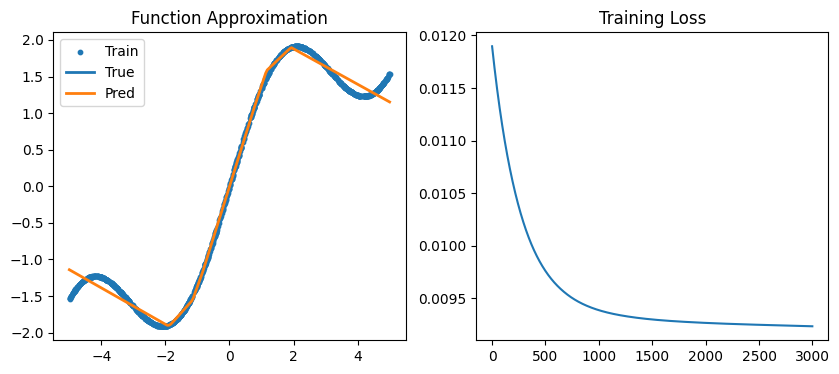

In [23]:

plt.figure(figsize=(10,4))

# 拟合效果
plt.subplot(1,2,1)
plt.scatter(x_train, y_train, s=10, label='Train')
plt.plot(x_test, y_test, label='True', linewidth=2)
plt.plot(x_test, y_pred, label='Pred', linewidth=2)
plt.legend()
plt.title("Function Approximation")

# loss曲线
plt.subplot(1,2,2)
plt.plot(loss_list)
plt.title("Training Loss")

plt.show()